# Section 2.2 — Multiple random variables

This notebook contains all the code examples from [Section 2.2 Multiple random variables](https://minireference.com/static/excerpts/noBSstats/noBSstats_ch02_PROB.pdf#page=40) in the **No Bullshit Guide to Statistics**.



#### Notebook setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# load Python modules
import matplotlib.pyplot as plt  # generic plotting functions
import numpy as np               # numerical calculations
import pandas as pd              # data frames to store joint PMFs
import seaborn as sns            # plotting distributions

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (5,3)},
)
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [4]:
# Simple float __repr__  
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

# set random seed for repeatability
np.random.seed(42)

## Definitions

In [5]:
pXY = [[ 0.1, 0.05, 0.02, 0.01, 0.01],
       [0.06, 0.12, 0.06, 0.03, 0.03],
       [0.02, 0.06, 0.12, 0.07, 0.02],
       [0.01, 0.01, 0.05,  0.1, 0.05]]
jpmfXY = pd.DataFrame(data=pXY,
                      index=["a", "b", "c", "d"],
                      columns=[1,2,3,4,5])
jpmfXY.columns.name = "X"
jpmfXY.index.name = "Y"
# print(jpmfXY.sum().sum())
jpmfXY

X,1,2,3,4,5
Y,,,,,
a,0.10,0.05,0.02,0.01,0.01
b,0.06,0.12,0.06,0.03,0.03
c,0.02,0.06,0.12,0.07,0.02
d,0.01,0.01,0.05,0.10,0.05


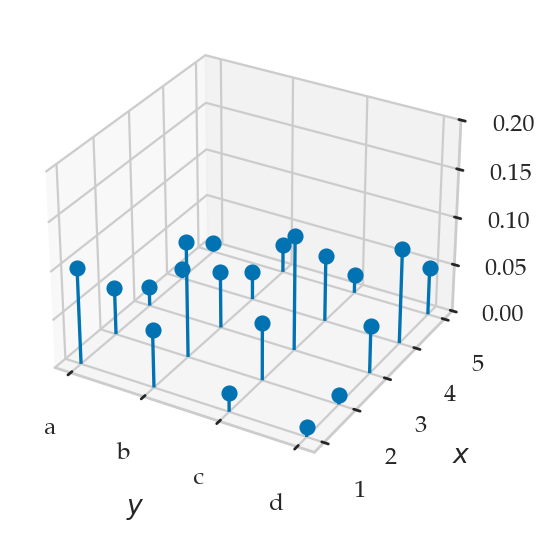

In [6]:
from ministats.plots.probability import plot_joint_pmf_stems
ax = plot_joint_pmf_stems(jpmfXY.T, zmax=0.2)
# ax.view_init(elev=30, azim=-30)
# ax.set_box_aspect((4, 5, 3))

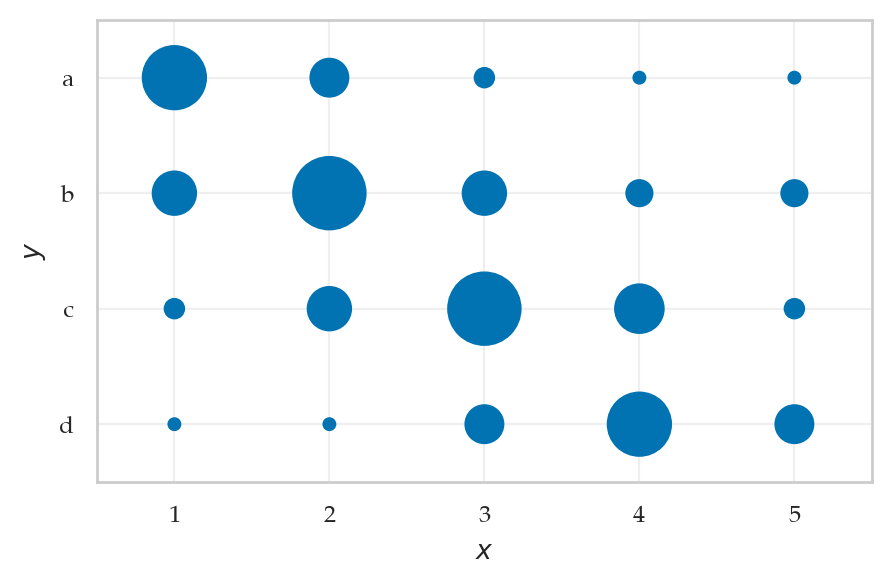

In [7]:
from ministats.plots.probability import plot_joint_pmf_balloons
plot_joint_pmf_balloons(jpmfXY);

In [8]:
print(sum(jpmfXY.loc["b"]))
print(jpmfXY.loc["b"].values)
print(jpmfXY.loc["b"].values / sum(jpmfXY.loc["b"]))

0.3
[0.06 0.12 0.06 0.03 0.03]
[0.2 0.4 0.2 0.1 0.1]


In [9]:
from ministats.book.tables import joint_pmf_to_array
joint_pmf_to_array(jpmfXY, sigfigs=3)

<IPython.core.display.Latex object>

### Marginal distributions

### Conditional distributions

## Joint probability distributions

#### Example 1: two coin tosses

In [10]:
def fC(c):
    if c in ["heads", "tails"]:
        return 1/2
    else:
        return 0

def fC1C2(c1,c2):
    return fC(c1) * fC(c2)

for c1 in ["heads", "tails"]:
    for c2 in ["heads", "tails"]:
        print("Pr(" + c1 + "," + c2 + ") =", fC1C2(c1,c2))

Pr(heads,heads) = 0.25
Pr(heads,tails) = 0.25
Pr(tails,heads) = 0.25
Pr(tails,tails) = 0.25


In [11]:
import pandas as pd

#        C1=heads    C1=tails
pC1C2 = [[0.25,      0.25   ],   # C2=heads
         [0.25,      0.25   ]]   # C2=tails

jpmfC1C2 = pd.DataFrame(data=pC1C2,
                        columns=["heads", "tails"],
                        index=["heads", "tails"])
jpmfC1C2.columns.name = "C_1"
jpmfC1C2.index.name = "C_2"

In [12]:
from ministats.book.tables import joint_pmf_to_array
joint_pmf_to_array(jpmfC1C2, sigfigs=3)

<IPython.core.display.Latex object>

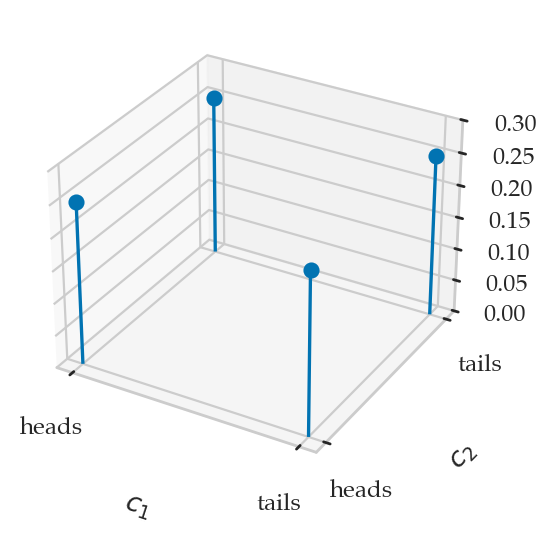

In [13]:
from ministats.plots.probability import plot_joint_pmf_stems

plot_joint_pmf_stems(jpmfC1C2, zmax=0.3);
ax.text2D(1.15, 0.56, "$f_{C_1C_2}$", transform=ax.transAxes,
          fontsize=plt.rcParams["axes.labelsize"],
          rotation=90, va="center", ha="center");

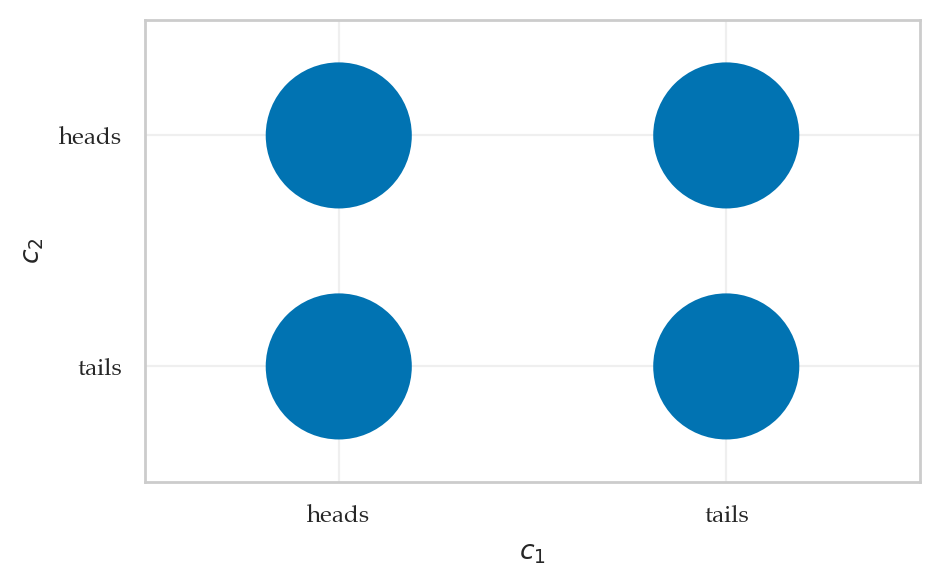

In [14]:
from ministats.plots.probability import plot_joint_pmf_balloons
plot_joint_pmf_balloons(jpmfC1C2);

TODO: show tree diagram

In [15]:
# Define the outcomes of the event "at least one heads"
event = [("heads","tails"), ("tails","heads"), ("heads","heads")]

# Probability the event {at least one `heads`}
sum([fC1C2(c1,c2) for (c1,c2) in event])

0.75

#### Example 2: rolling two dice

In [16]:
def fD(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

def fD1D2(d1,d2):
    return fD(d1) * fD(d2)


In [17]:
#         D1=1  D1=2  D1=3  D1=4  D1=5  D1=6
pD1D2 = [[1/36, 1/36, 1/36, 1/36, 1/36, 1/36],  # D2=1
         [1/36, 1/36, 1/36, 1/36, 1/36, 1/36],  # D2=2
         [1/36, 1/36, 1/36, 1/36, 1/36, 1/36],  # D2=3
         [1/36, 1/36, 1/36, 1/36, 1/36, 1/36],  # D2=4
         [1/36, 1/36, 1/36, 1/36, 1/36, 1/36],  # D2=5
         [1/36, 1/36, 1/36, 1/36, 1/36, 1/36]]  # D2=6
jpmfD1D2 = pd.DataFrame(data=pD1D2,
                        columns=[1,2,3,4,5,6],
                        index=[1,2,3,4,5,6])
jpmfD1D2.columns.name = "D_1"
jpmfD1D2.index.name = "D_2"

In [18]:
joint_pmf_to_array(jpmfD1D2, sigfigs=3)

<IPython.core.display.Latex object>

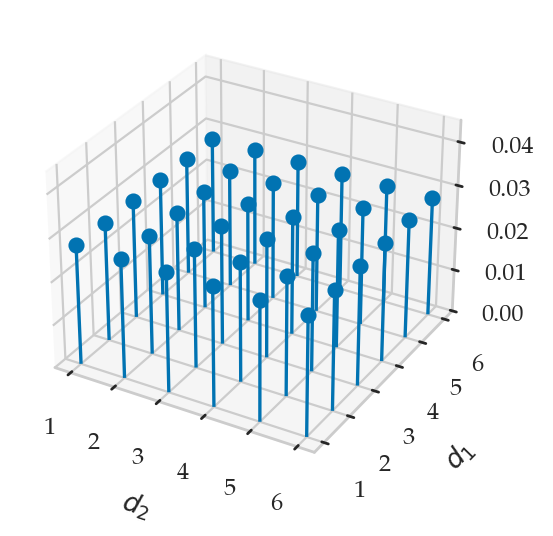

In [19]:
from ministats.plots.probability import plot_joint_pmf_stems
plot_joint_pmf_stems(jpmfD1D2.T, zmax=0.045);

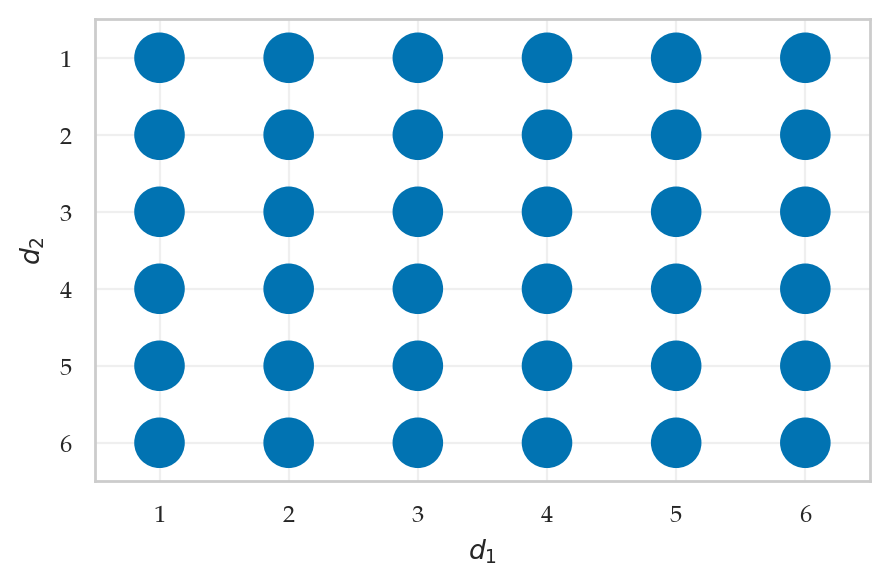

In [20]:
from ministats.plots.probability import plot_joint_pmf_balloons
plot_joint_pmf_balloons(jpmfD1D2);

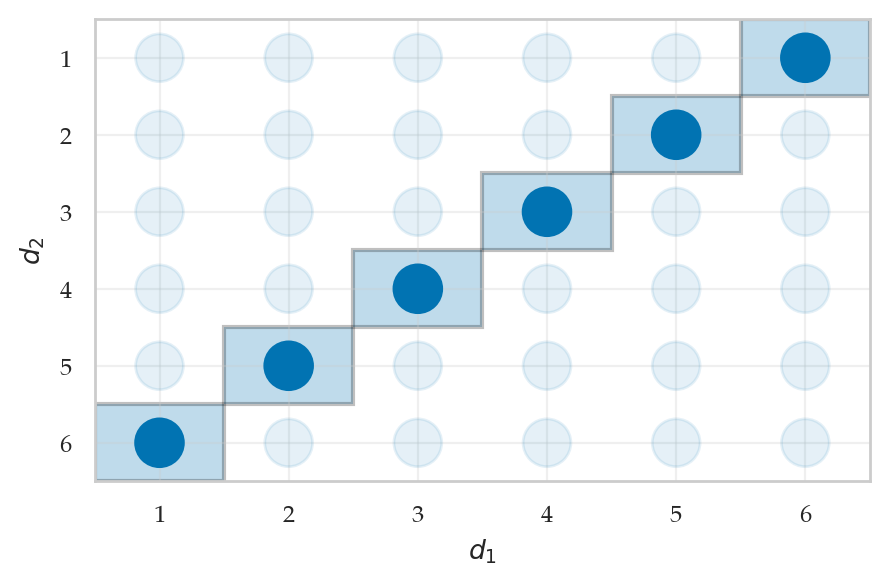

In [21]:
sum_to_seven = [(1,6),(2,5),(3,4),(4,3),(5,2),(6,1)]
plot_joint_pmf_balloons(jpmfD1D2, highlight=sum_to_seven);

### Marginal distribution functions

In [22]:
joint_pmf_to_array(jpmfXY, sigfigs=2, margins=True)

<IPython.core.display.Latex object>

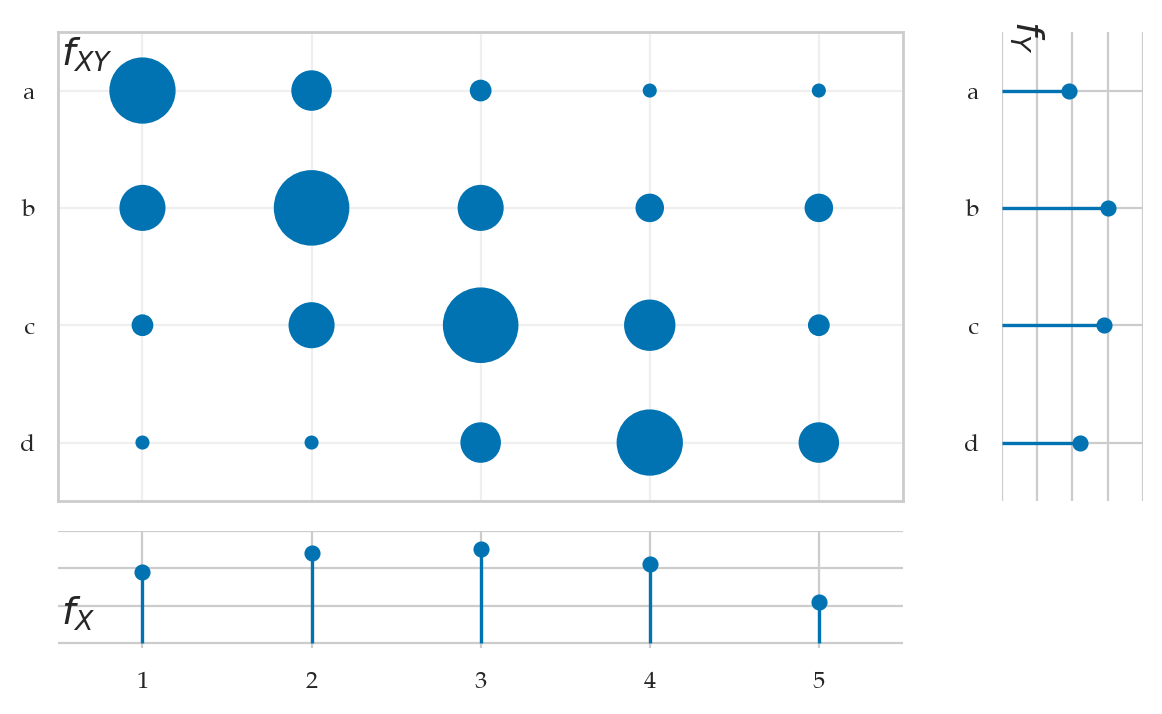

In [23]:
from ministats.plots.probability import plot_joint_pmf_and_marginals
plot_joint_pmf_and_marginals(jpmfXY);

## Conditional distributions

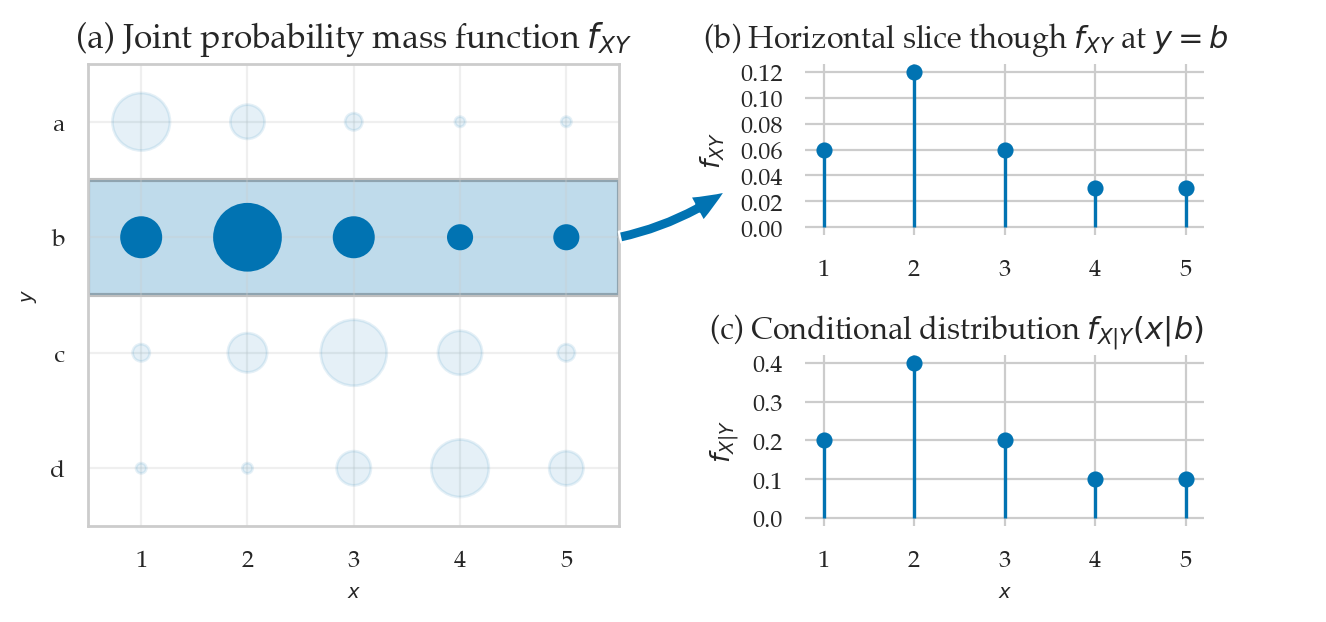

In [24]:
from ministats.plots.probability import plot_joint_pmf_and_conditional
plot_joint_pmf_and_conditional(jpmfXY, given="y");

The conditional distribution $f_{X|Y}(x|y=b)$ is obtained as follows.

In [25]:
# f_{X|Y}(x|y=b)
jpmfXY.loc["b",:] / jpmfXY.loc["b",:].sum()

X
1    0.2
2    0.4
3    0.2
4    0.1
5    0.1
Name: b, dtype: float64

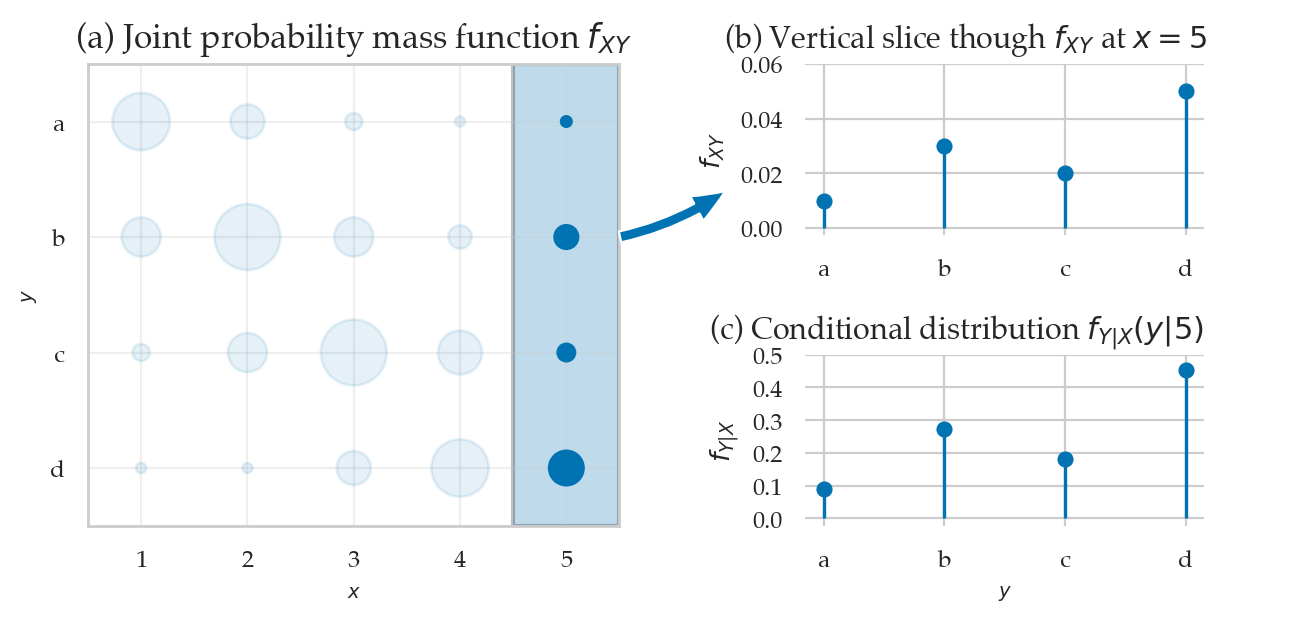

In [26]:
plot_joint_pmf_and_conditional(jpmfXY, given="x");

The conditional distribution $f_{Y|X}(y|x=5)$ is obtained as follows.

In [27]:
# f_{Y|X}(y|x=5)
jpmfXY.loc[:,5] / jpmfXY.loc[:,5].sum()

Y
a    0.090909
b    0.272727
c    0.181818
d    0.454545
Name: 5, dtype: float64

#### Example 3: coin-dependent dice roll

In [28]:
def fC(c):
    if c in ["heads", "tails"]:
        return 1/2
    else:
        return 0

def fD6(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

def fD4(d):
    if d in [1,2,3,4]:
        return 1/4
    else:
        return 0

def fDC(d,c):
    if c == "heads":
        return fC(c) * fD6(d)
    elif c == "tails":
        return fC(c) * fD4(d)

for c in ["heads", "tails"]:
    for d in [1,2,3,4,5,6]:
        print("Pr(" + str(d) + "," + c + ") =", round(fDC(d,c),4))

Pr(1,heads) = 0.0833
Pr(2,heads) = 0.0833
Pr(3,heads) = 0.0833
Pr(4,heads) = 0.0833
Pr(5,heads) = 0.0833
Pr(6,heads) = 0.0833
Pr(1,tails) = 0.125
Pr(2,tails) = 0.125
Pr(3,tails) = 0.125
Pr(4,tails) = 0.125
Pr(5,tails) = 0.0
Pr(6,tails) = 0.0


In [29]:
sum(fDC(d,c) for d in [1,2,3,4,5,6] for c in ["heads", "tails"])

1.0

In [30]:
# f_{Y|X}(y|heads)  [as a list]
[fDC(d,"heads") for d in range(1,6+1)]

[0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333]

In [31]:
# f_{Y|X}(y|tails)  [as a list]
[fDC(d,"tails") for d in range(1,6+1)]

[0.125, 0.125, 0.125, 0.125, 0.0, 0.0]

In [32]:
# f_Y(y)    [as a list]
fDs = [fDC(d,"heads")+fDC(d,"tails") for d in range(1,6+1)]
fDs

[0.20833333333333331,
 0.20833333333333331,
 0.20833333333333331,
 0.20833333333333331,
 0.08333333333333333,
 0.08333333333333333]

In [33]:
# ALT. compute f_{D|C}(d|heads)*0.5 + f_{D|C}(d|tails)*0.5
fDs = [fD6(d)*0.5+fD4(d)*0.5 for d in range(1,6+1)]
fDs

[0.20833333333333331,
 0.20833333333333331,
 0.20833333333333331,
 0.20833333333333331,
 0.08333333333333333,
 0.08333333333333333]

In [34]:
sum(fDs)

0.9999999999999999

In [35]:
import pandas as pd
#       D=1   D=3   D=3   D=4   D=5   D=6
pDC = [[1/12, 1/12, 1/12, 1/12, 1/12, 1/12],  # C=heads
       [1/8,  1/8,  1/8,  1/8,  0,    0]]     # C=tails
jpmfDC = pd.DataFrame(data=pDC,
                      index=["heads","tails"],
                      columns=[1,2,3,4,5,6])
jpmfDC.columns.name = "D"
jpmfDC.index.name = "C"

In [36]:
from ministats.book.tables import joint_pmf_to_array
joint_pmf_to_array(jpmfDC, sigfigs=3, margins=True)

<IPython.core.display.Latex object>

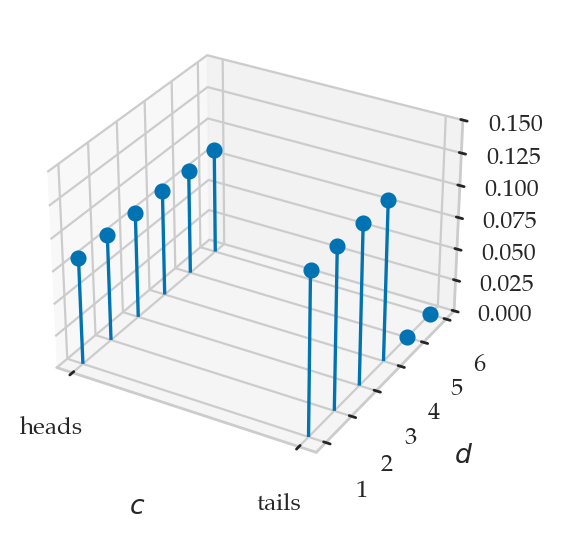

In [37]:
from ministats.plots.probability import plot_joint_pmf_stems
ax = plot_joint_pmf_stems(jpmfDC.T)

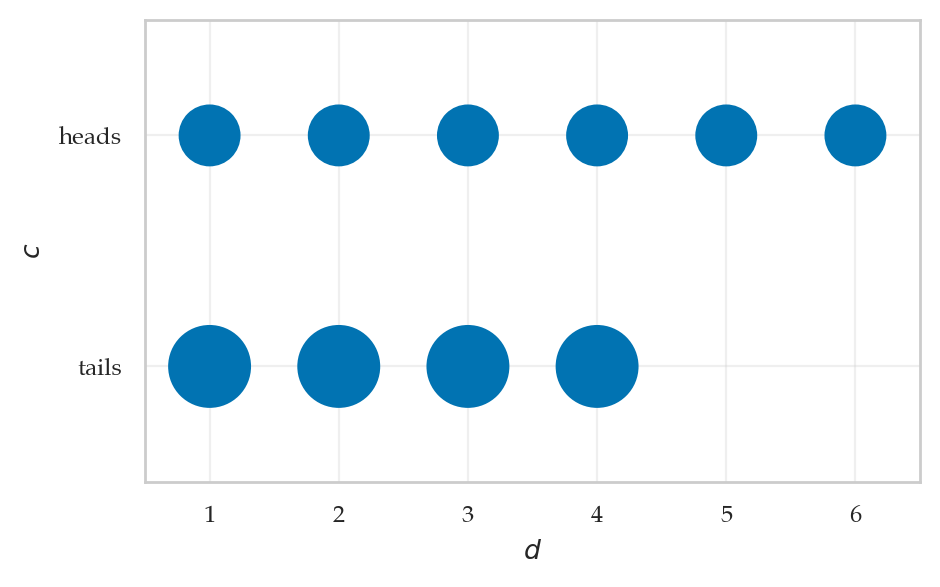

In [38]:
from ministats.plots.probability import plot_joint_pmf_balloons
plot_joint_pmf_balloons(jpmfDC);

#### Example 4: diagnostic test

In [39]:
def fV(v):
    if v == 1:
        return 0.03
    elif v == 0:
        return 0.97

def fTgivenV1(t):
    if t == 1:
        return 0.90
    elif t == 0:
        return 0.10

def fTgivenV0(t):
    if t == 1:
        return 0.20
    elif t == 0:
        return 0.80

def fTgivenV(t,v):
    if v == 1:
        return fTgivenV1(t)
    elif v == 0:
        return fTgivenV0(t)

def fTV(t,v):
    return fTgivenV(t,v) * fV(v)

for v in range(0,1+1):
    for t in range(0,1+1):
        print("Pr({T=" + str(t) + ",V=" + str(v)+"})",
              "=", fTgivenV(t,v), "*", fV(v),
              "=", round(fTV(t,v),4))

Pr({T=0,V=0}) = 0.8 * 0.97 = 0.776
Pr({T=1,V=0}) = 0.2 * 0.97 = 0.194
Pr({T=0,V=1}) = 0.1 * 0.03 = 0.003
Pr({T=1,V=1}) = 0.9 * 0.03 = 0.027


In [40]:
import pandas as pd

#              T = 0           T = 1 
pTV = [[       0.8*0.97,  (1-0.8)*0.97],    #   V = 0
        [  (1-0.9)*0.03,      0.9*0.03]]    #   V = 1

jpmfTV = pd.DataFrame(data=pTV, columns=[0,1], index=[0,1])
jpmfTV.columns.name = "T"
jpmfTV.index.name = "V"

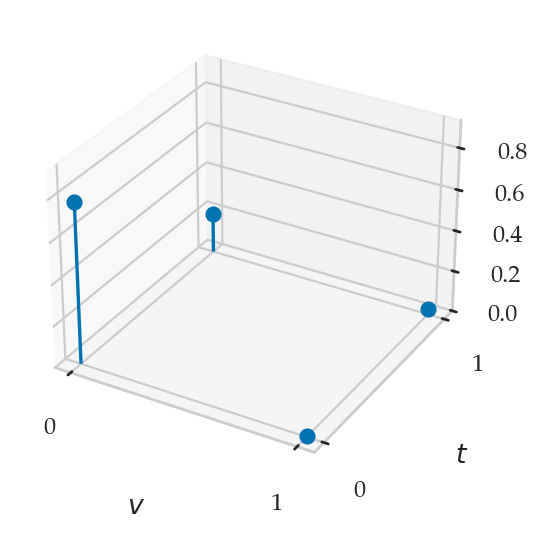

In [41]:
plot_joint_pmf_stems(jpmfTV.T);

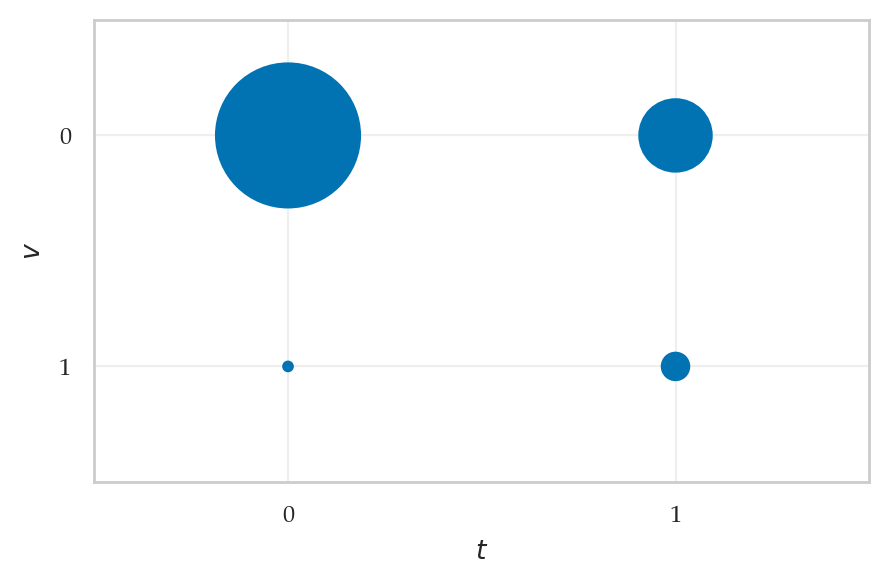

In [42]:
from ministats.plots.probability import plot_joint_pmf_balloons
plot_joint_pmf_balloons(jpmfTV, size_exponent=1);

In [43]:
from ministats.book.tables import joint_pmf_to_array
joint_pmf_to_array(jpmfTV, sigfigs=3, margins=True)

<IPython.core.display.Latex object>

In [44]:
# f_T(0) = 
0.8 * 0.97 + 0.10 * 0.03

0.779

In [45]:
# f_T(1) = 
0.2 * 0.97 + 0.90 * 0.03

0.221

In [46]:
for t in range(0,1+1):
    fTt = fTV(t,0) + fTV(t,1)
    print("Pr({T="+str(t)+"}) =", fTt)

Pr({T=0}) = 0.779
Pr({T=1}) = 0.221


## Bayes' rule


### Example 4: diagnostic test (continued)

We're now interested in $f_{V|T}(v|t)$,
which we can obtain using Bayes' theorem.

$$
    f_{V|T}(v|t)
        = \frac{ f_{T|V}(t|v) f_V(v) }{ f_{T|V}(t|0) f_V(0) + f_{T|V}(t|1) f_V(1)}.
$$

We'll now define the function `fVgivenT` that computes the numerator
and denominator in this fraction,
and returns the ratio.

In [47]:
def fVgivenT(v,t):
    num = fTgivenV(t,v) * fV(v)
    denom = fTgivenV(t,0) * fV(0) + fTgivenV(t,1) * fV(1)
    return num / denom

The probability of the patient having the virus $f_{V|T}(1|t=1)$,
given they tested positive is:

In [48]:
fVgivenT(1,1)

0.12217194570135746

Intuitively,
this percentage is measuring the ratio of the probability of the outcome $f_{VT}(1,1)$
divided by sum of the probabilities of all outcomes where positive test can occur:
$f_{VT}(1,1)+f_{VT}(0,1)$.

In [49]:
fTV(1,1) / (fTV(1,0) + fTV(1,1))

0.12217194570135746

## Multivariable expectations

### Covariance

### Correlation

## Independent random variables

### Formulas for independent random variables

### Independent, identically distributed variables

### Example 5: tossing a coin $n$ times

### Example 6: rolling a die $n$ times

## Discussion

### Dependence and independence

## Exercises

See the notebook [sec22_multiple_discrete_RVs.ipynb](../exercsies/sec22_multiple_discrete_RVs.ipynb).

## Links